<div align="center">
  <span style="color: red; font-size: 4em; font-weight: bold;">
    Question 8
  </span>
</div>

In [8]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from ISLP import load_data
from matplotlib.pyplot import subplots
from ISLP.models import summarize, ModelSpec as MS
from statsmodels.stats.anova import anova_lm
import statsmodels.formula.api as smf

## (a)

In [9]:
auto = load_data('Auto')
auto =auto.reset_index()
auto.head()

,name,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
0,chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
1,buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
2,plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
3,amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
4,ford torino,17.0,8,302.0,140,3449,10.5,70,1


In [10]:
X = pd.DataFrame({'Intercept': np.ones(auto.shape[0]),
                  'horsepower': auto['horsepower']})
X.head()

,Intercept,horsepower
0,1.0,130
1,1.0,165
2,1.0,150
3,1.0,150
4,1.0,140


In [11]:
Y = auto['mpg']
model = sm.OLS(Y, X)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     599.7
Date:                Fri, 13 Mar 2026   Prob (F-statistic):           7.03e-81
Time:                        20:22:46   Log-Likelihood:                -1178.7
No. Observations:                 392   AIC:                             2361.
Df Residuals:                     390   BIC:                             2369.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     39.9359      0.717     55.660      0.000      38.525      41.347
horsepower    -0.1578      0.006    -24.489      0.000      -0.171      -0.145
==============================================================================
Omnibus:                       16.432   Durbin-Watson:                   0.920
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               17.305
Skew:                           0.492   Prob(JB):                     0.000175
Kurtosis:                       3.299   Cond. No.                         322.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [12]:
results.params

Intercept     39.935861
horsepower    -0.157845
dtype: float64

In [13]:
newX = pd.DataFrame({'Intercept': 1,
                     'horsepower': [98]})
predicted = results.predict(newX)
predicted

0    24.467077
dtype: float64

In [14]:
predictions = results.get_prediction(newX)
pred_summary = predictions.summary_frame(alpha=0.05)
pred_summary
# mean_ci_lower & upper: confidence interval and obs_ci_lower & upper: prediction interval

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,24.467077,0.251262,23.973079,24.961075,14.809396,34.124758


## (b)

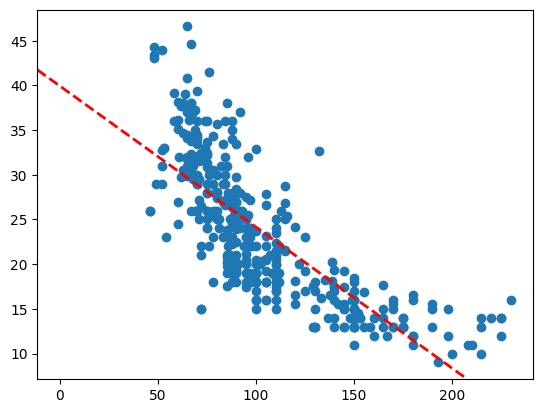

In [15]:
fig, ax = subplots()
ax.scatter(auto['horsepower'], auto['mpg'])
ax.axline((0, results.params.iloc[0]),
          slope = results.params.iloc[1],
          color = 'red',
          ls = '--',
          linewidth = 2)


## (c)

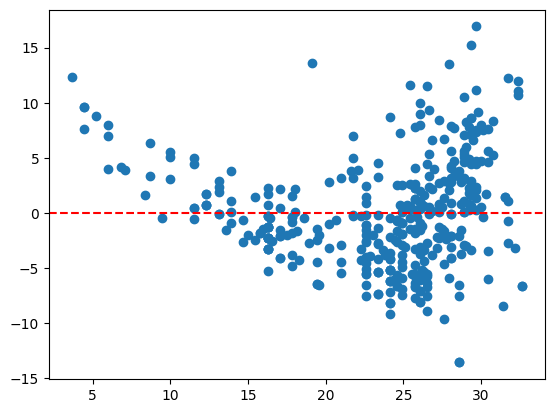

In [16]:
ax = subplots()[1]
ax.scatter(results.fittedvalues, results.resid)
ax.axhline(0, color='red', linestyle='--')



this residual plot shows pattern of shape u, so non-linear relationship might exist between them, so leverage matrix is also plotted in next graph


np.int64(115)

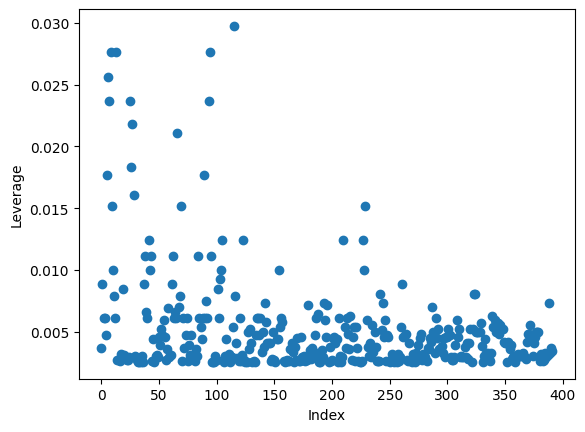

In [17]:
infl = results.get_influence()
ax = subplots()[1]
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)


this shows this is well behaved observation with predictor values that don't stand out.

<div align="center">
  <span style="color: red; font-size: 4em; font-weight: bold;">
    Question 9
  </span>
</div>

## (a)

In [18]:
Auto = load_data('Auto')
Auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1


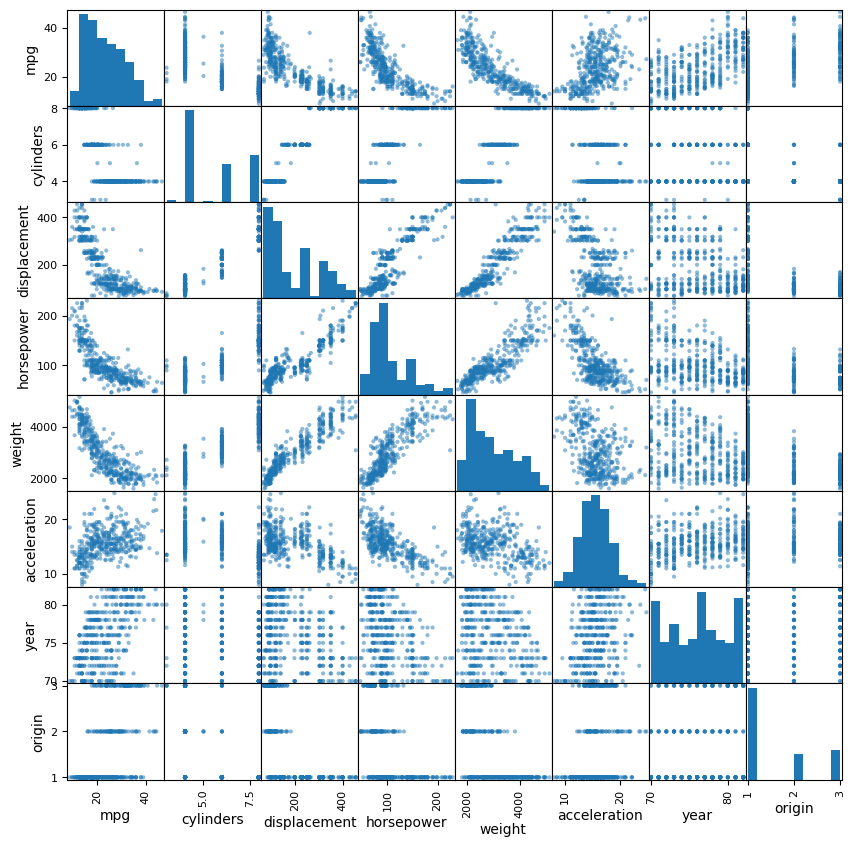

In [19]:
pd.plotting.scatter_matrix(Auto, figsize=(10,10));

## (b)

In [20]:
Auto.corr(numeric_only=True)

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746
year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000


## (c)

In [21]:
list = Auto.columns.drop('mpg')
X = MS(list).fit_transform(Auto)
Y = Auto['mpg']
model = sm.OLS(Y, X)
results = model.fit()
summarize(results)


,coef,std err,t,P>|t|
intercept,-17.2184,4.644,-3.707,0.000
cylinders,-0.4934,0.323,-1.526,0.128
displacement,0.0199,0.008,2.647,0.008
horsepower,-0.0170,0.014,-1.230,0.220
weight,-0.0065,0.001,-9.929,0.000
acceleration,0.0806,0.099,0.815,0.415
year,0.7508,0.051,14.729,0.000
origin,1.4261,0.278,5.127,0.000


### (i)

In [22]:
results1 = smf.ols('Y~X', data=Auto).fit()
anova_lm(results1)


,df,sum_sq,mean_sq,F,PR(>F)
X,8.0,19576.082069,2447.010259,220.979533,1.326882e-138
Residual,384.0,4252.212530,11.073470,NaN,NaN


### (ii)

displacement, weight, year and origin seems to have significant relationship to mpg as they have p value close to 0

### (iii)

if all other predictors are constant then when year is increased by 1, the mpg of car will increase by 0.75 meaning more recent the car manufactured more efficiency they carry

## (d)

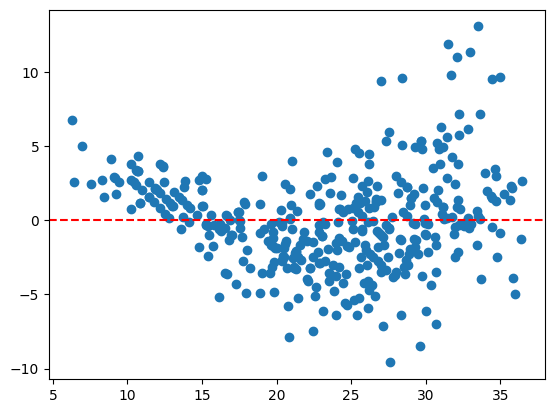

In [23]:
# residual plot
ax = subplots()[1]
ax.scatter(results1.fittedvalues, results1.resid)
ax.axhline(0, color='red', linestyle='--')

<Axes: >

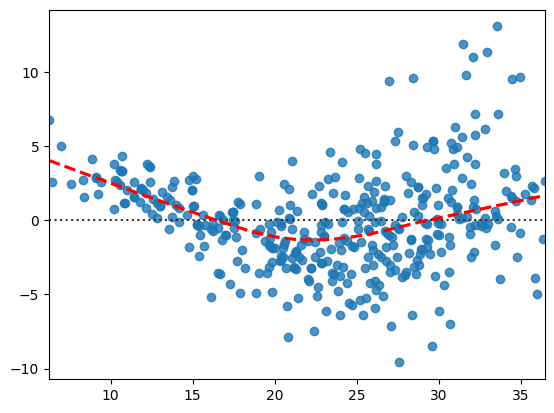

In [25]:
import seaborn as sns
sns.residplot(x=results1.fittedvalues, y=results1.resid, lowess=True,
              line_kws={'color': 'red', 'linestyle': '--'})


The curve suggests there is non-linearity relationship among the predictors

Text(0, 0.5, 'Studentized Residuals')

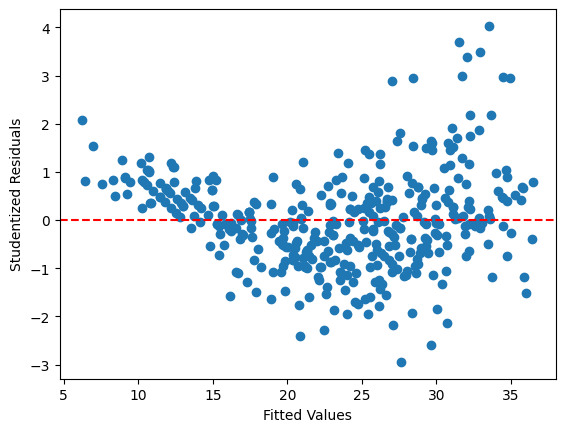

In [28]:
# Studentized Residual Plot
infl = results.get_influence()
stud_resid = infl.resid_studentized_external
ax = subplots()[1]
ax.scatter(results1.fittedvalues, stud_resid)
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel('Fitted Values')
ax.set_ylabel('Studentized Residuals')

In [29]:
# observations with studentized residuals greater than 3 in absolute value are often considered outliers
outliers = np.where(np.abs(stud_resid) > 3)[0]
print("Outliers (index):", outliers)

Outliers (index): [242 320 323 324]


np.int64(13)

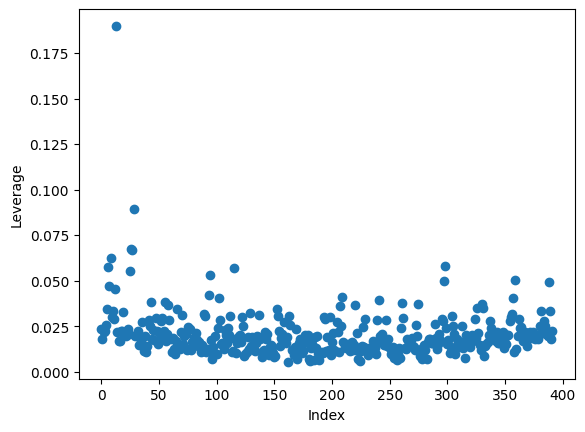

In [32]:
# leverage plot
ax = subplots()[1]
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)

the avg leverage value (p+1)/n is (8+1)/392 = 0.023 and here at index 13, leverage value is more than 0.175 which is way higher than avg value so it shows it may be dangerous and might invalidate the entrire model fit

In [43]:
Auto.corr()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746
year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000


## (e)

In [35]:
# use smf.ols for easy fit of model
result2 = smf.ols('mpg ~ year*displacement', data=Auto).fit()
result2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.774
Model:                            OLS   Adj. R-squared:                  0.772
Method:                 Least Squares   F-statistic:                     441.7
Date:                Fri, 13 Mar 2026   Prob (F-statistic):          1.04e-124
Time:                        20:55:50   Log-Likelihood:                -1070.1
No. Observations:                 392   AIC:                             2148.
Df Residuals:                     388   BIC:                             2164.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept           -72.8784      8.368     -8.709      0.000     -89.330     -56.427
year                  1.4077      0.110     12.779      0.000       1.191       1.624
displacement          0.2523      0.041      6.216      0.000       0.173       0.332
year:displacement    -0.0041      0.001     -7.482      0.000      -0.005      -0.003
==============================================================================
Omnibus:                       42.582   Durbin-Watson:                   1.373
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               89.987
Skew:                           0.593   Prob(JB):                     2.88e-20
Kurtosis:                       5.026   Cond. No.                     7.32e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.32e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [38]:
result3 = smf.ols('mpg ~ weight + horsepower*displacement + year', data=Auto).fit()
summarize(result3)

,coef,std err,t,P>|t|
Intercept,-3.8049,3.742000,-1.017,0.31
weight,-0.0040,0.001000,-7.231,0.00
horsepower,-0.1624,0.017000,-9.815,0.00
displacement,-0.0630,0.007000,-8.556,0.00
horsepower:displacement,0.0005,0.000043,11.345,0.00
year,0.7466,0.045000,16.420,0.00


## (f)

In [45]:
model2 = smf.ols('mpg ~ np.square(horsepower) + horsepower + weight', data=Auto)
results2 = model2.fit()
summarize(results2)

,coef,std err,t,P>|t|
Intercept,55.9864,1.649,33.953,0.0
np.square(horsepower),0.0008,0.000,7.040,0.0
horsepower,-0.2838,0.035,-8.067,0.0
weight,-0.0045,0.001,-8.809,0.0


In [46]:
model3 = smf.ols('mpg~ np.log(weight) + year + weight', data=Auto)
results3 = model3.fit()
summarize(results3)

,coef,std err,t,P>|t|
Intercept,284.2873,29.393,9.672,0.0
np.log(weight),-43.5906,4.259,-10.235,0.0
year,0.8287,0.045,18.620,0.0
weight,0.0078,0.001,5.473,0.0


In [48]:
model4 = smf.ols('mpg ~ year + np.sqrt(year) + displacement', data=Auto)
results4 = model4.fit()
summarize(results4)

,coef,std err,t,P>|t|
Intercept,2379.2140,355.748,6.688,0.0
year,32.3055,4.688,6.890,0.0
np.sqrt(year),-550.8847,81.699,-6.743,0.0
displacement,-0.0508,0.002,-25.875,0.0


<div align="center">
  <span style="color: red; font-size: 4em; font-weight: bold;">
    Question 10
  </span>
</div>

In [53]:
carseats = load_data('Carseats')
print(carseats.columns)
carseats.head()

Index(['Sales', 'CompPrice', 'Income', 'Advertising', 'Population', 'Price',
       'ShelveLoc', 'Age', 'Education', 'Urban', 'US'],
      dtype='object')


,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


## (a)

In [52]:
model = smf.ols('Sales ~ Price + Urban + US', data=carseats)
result = model.fit()
summarize(result)

,coef,std err,t,P>|t|
Intercept,13.0435,0.651,20.036,0.000
Urban[T.Yes],-0.0219,0.272,-0.081,0.936
US[T.Yes],1.2006,0.259,4.635,0.000
Price,-0.0545,0.005,-10.389,0.000


## (b)

The relation betn urban and sales is not significant. The coeff of us is positive which implies that if it is located in us then the sales is bound to increase but it has inverse relation with price, if price is increased by a unit sales is decreased by factor 0.0545.

## (c)

 Sales = 13.045 - 0.0219 * Urban + 1.20060 * US - 0.0545*Price 

 value of urban is 1 if its value is yes and 0 if it is no and same for us

## (d)

we can reject null hypothesis for US and price as their p value is close to 0 but can't reject for Urban.

## (e)

In [56]:
model1 = smf.ols('Sales ~ US + Price', data=carseats)
results1 = model1.fit()
summarize(results1)

,coef,std err,t,P>|t|
Intercept,13.0308,0.631,20.652,0.0
US[T.Yes],1.1996,0.258,4.641,0.0
Price,-0.0545,0.005,-10.416,0.0


## (f)

In [57]:
# we can compare how well the models fit by calculating R² for both models
print(result.rsquared)
print(results1.rsquared)

0.23927539218405547
0.23926288842678567
